# HD 108236 (TOI-1233) with Miletos

[Daylan et al. (2021a)](https://doi.org/10.3847/1538-3881/abd73e) reported four transiting planets in TESS observations of HD 108236. This notebook runs Miletos's maintained observational pipeline on the local TOI-1233 TESS photometry and PFS radial velocities, then displays the pipeline's phase-folded TESS transits for planets b–e. The pipeline uses the current five-planet model and later PFS data. It does not rerun the paper's allesfitter fit or reproduce its published posterior. The observational input files under `$MILETOS_PATH/data/TOI-1233/data/` must be available before execution.

In [1]:
from pathlib import Path

from IPython.display import Image, display

from miletos.toi1233 import run_toi1233_observation
from tdpy.verbosity import print as narrate

## Run the observational pipeline

Miletos loads the target's local TESS and PFS measurements, evaluates the planetary-system configuration, and writes its usual phase curves and summary pages.

Analyzed target: TOI-1233


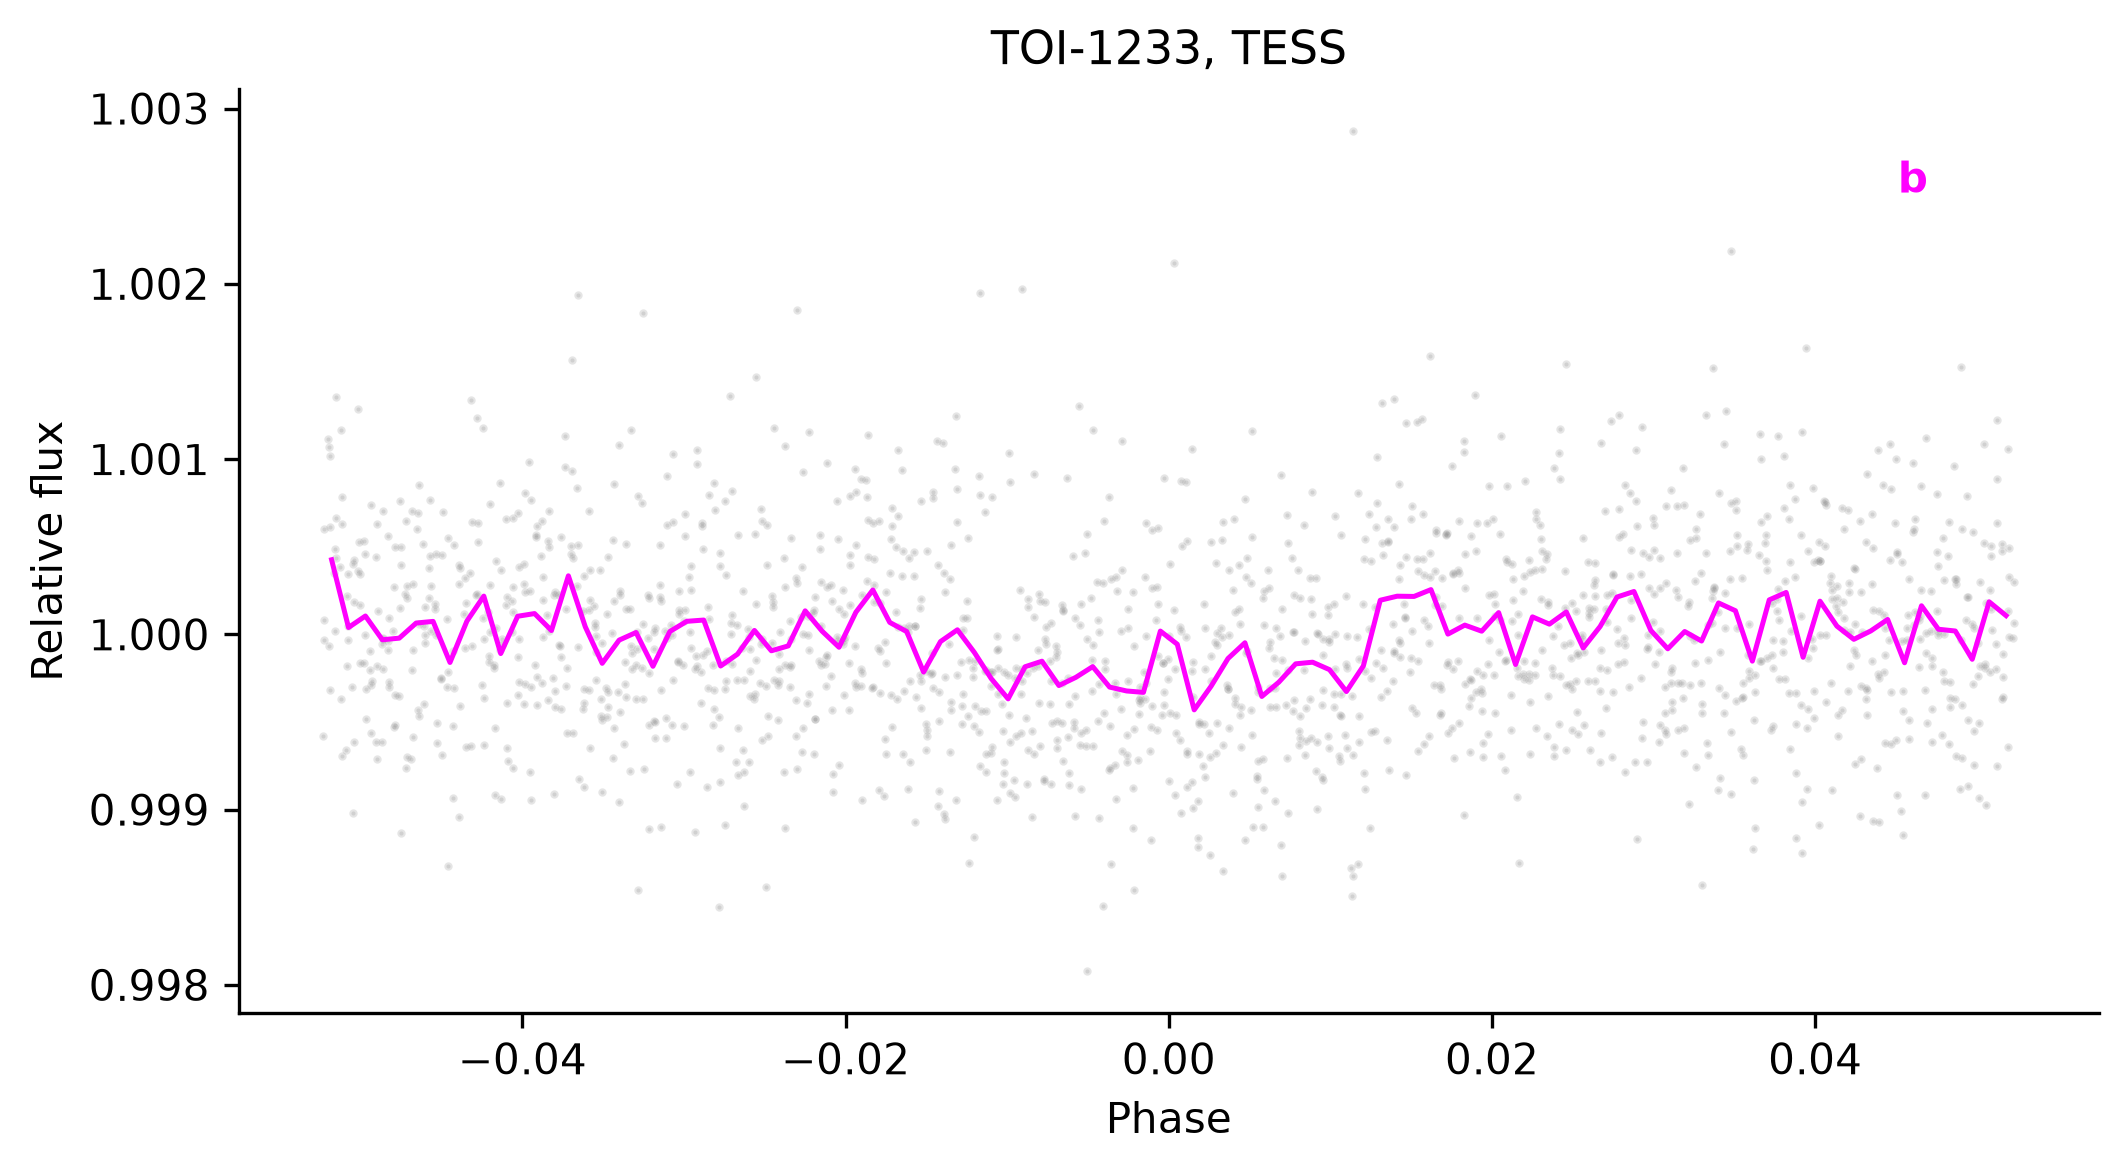

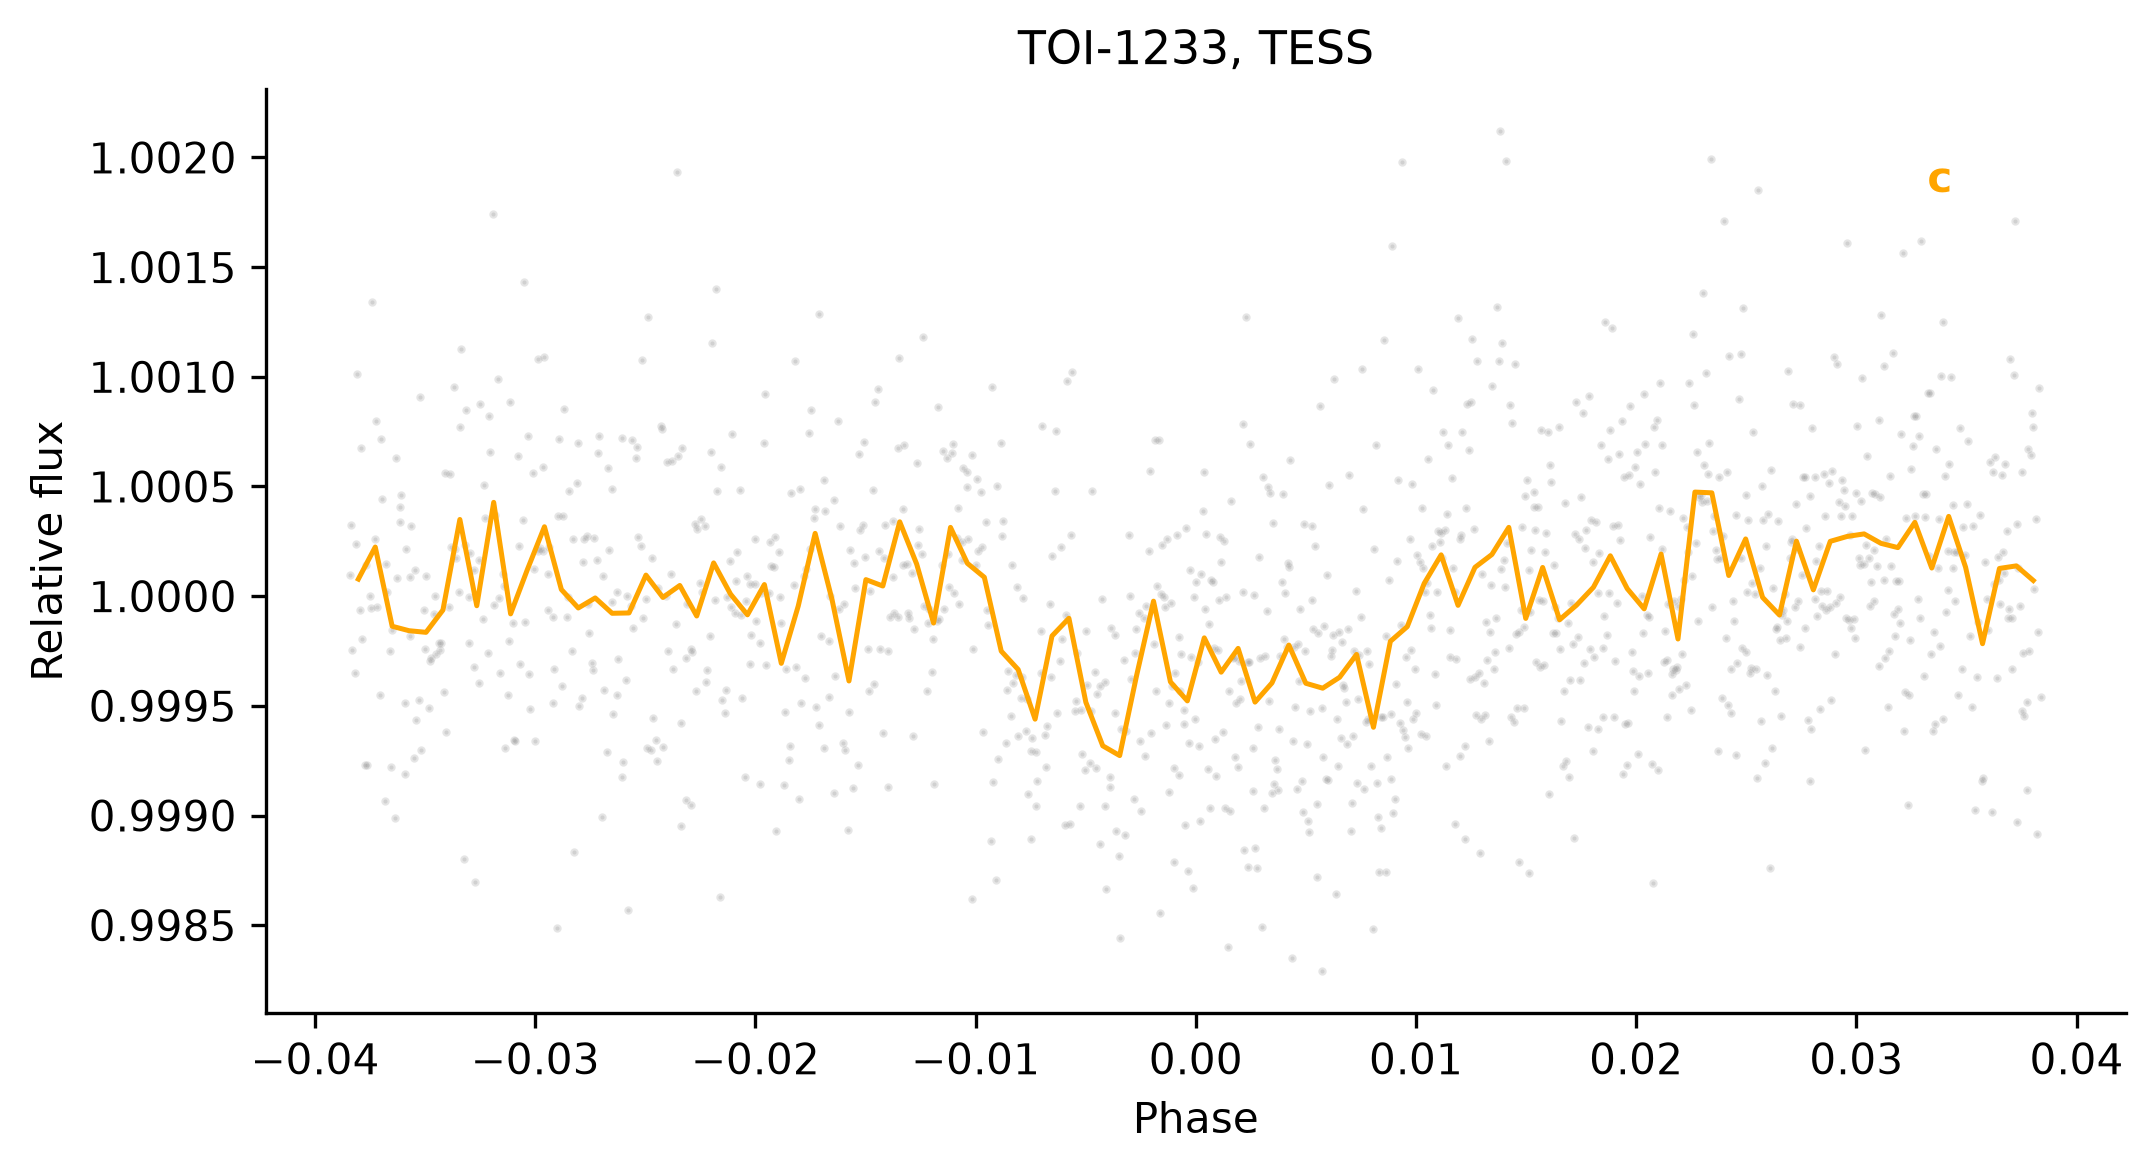

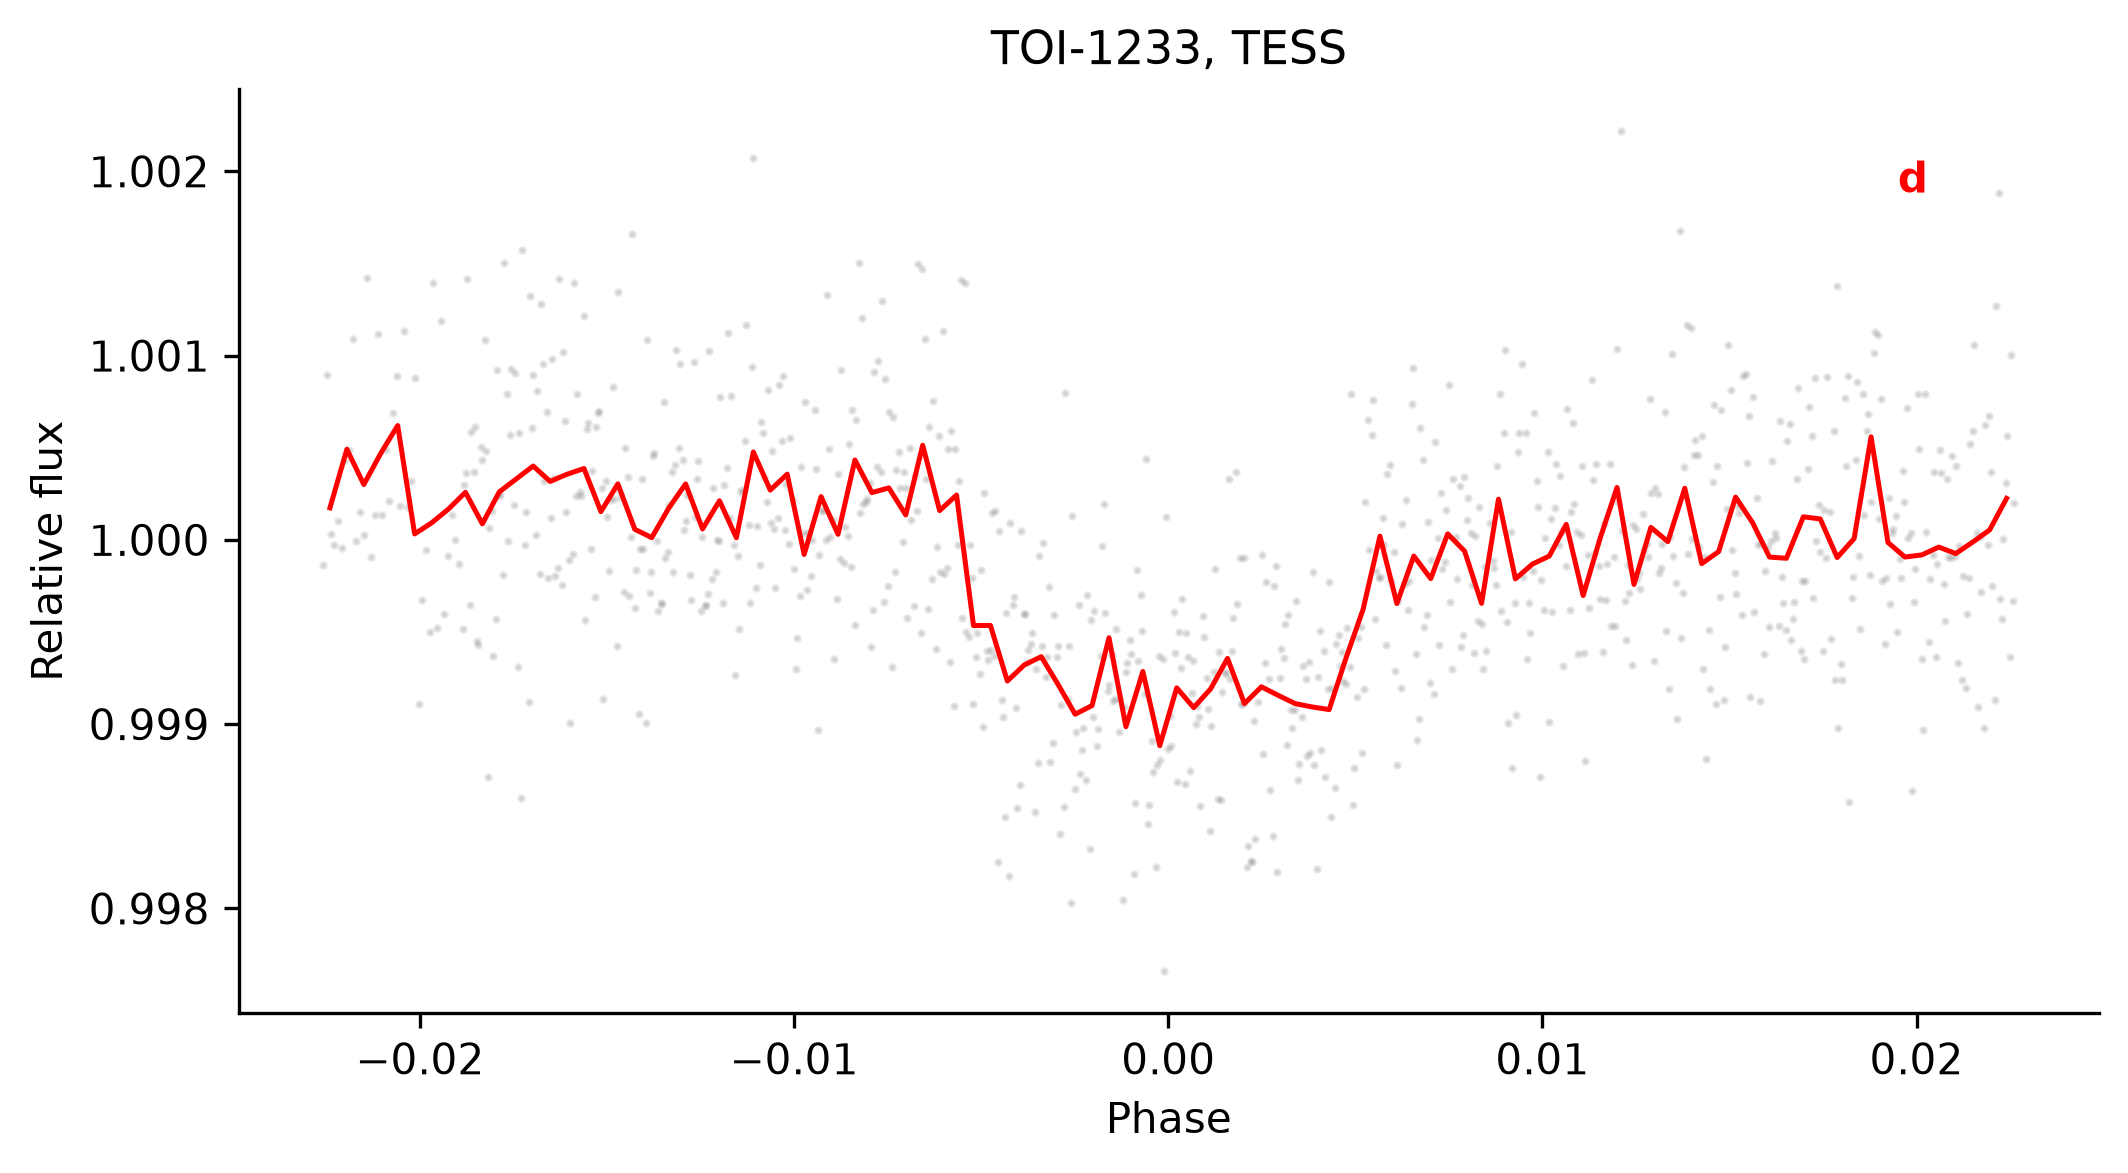

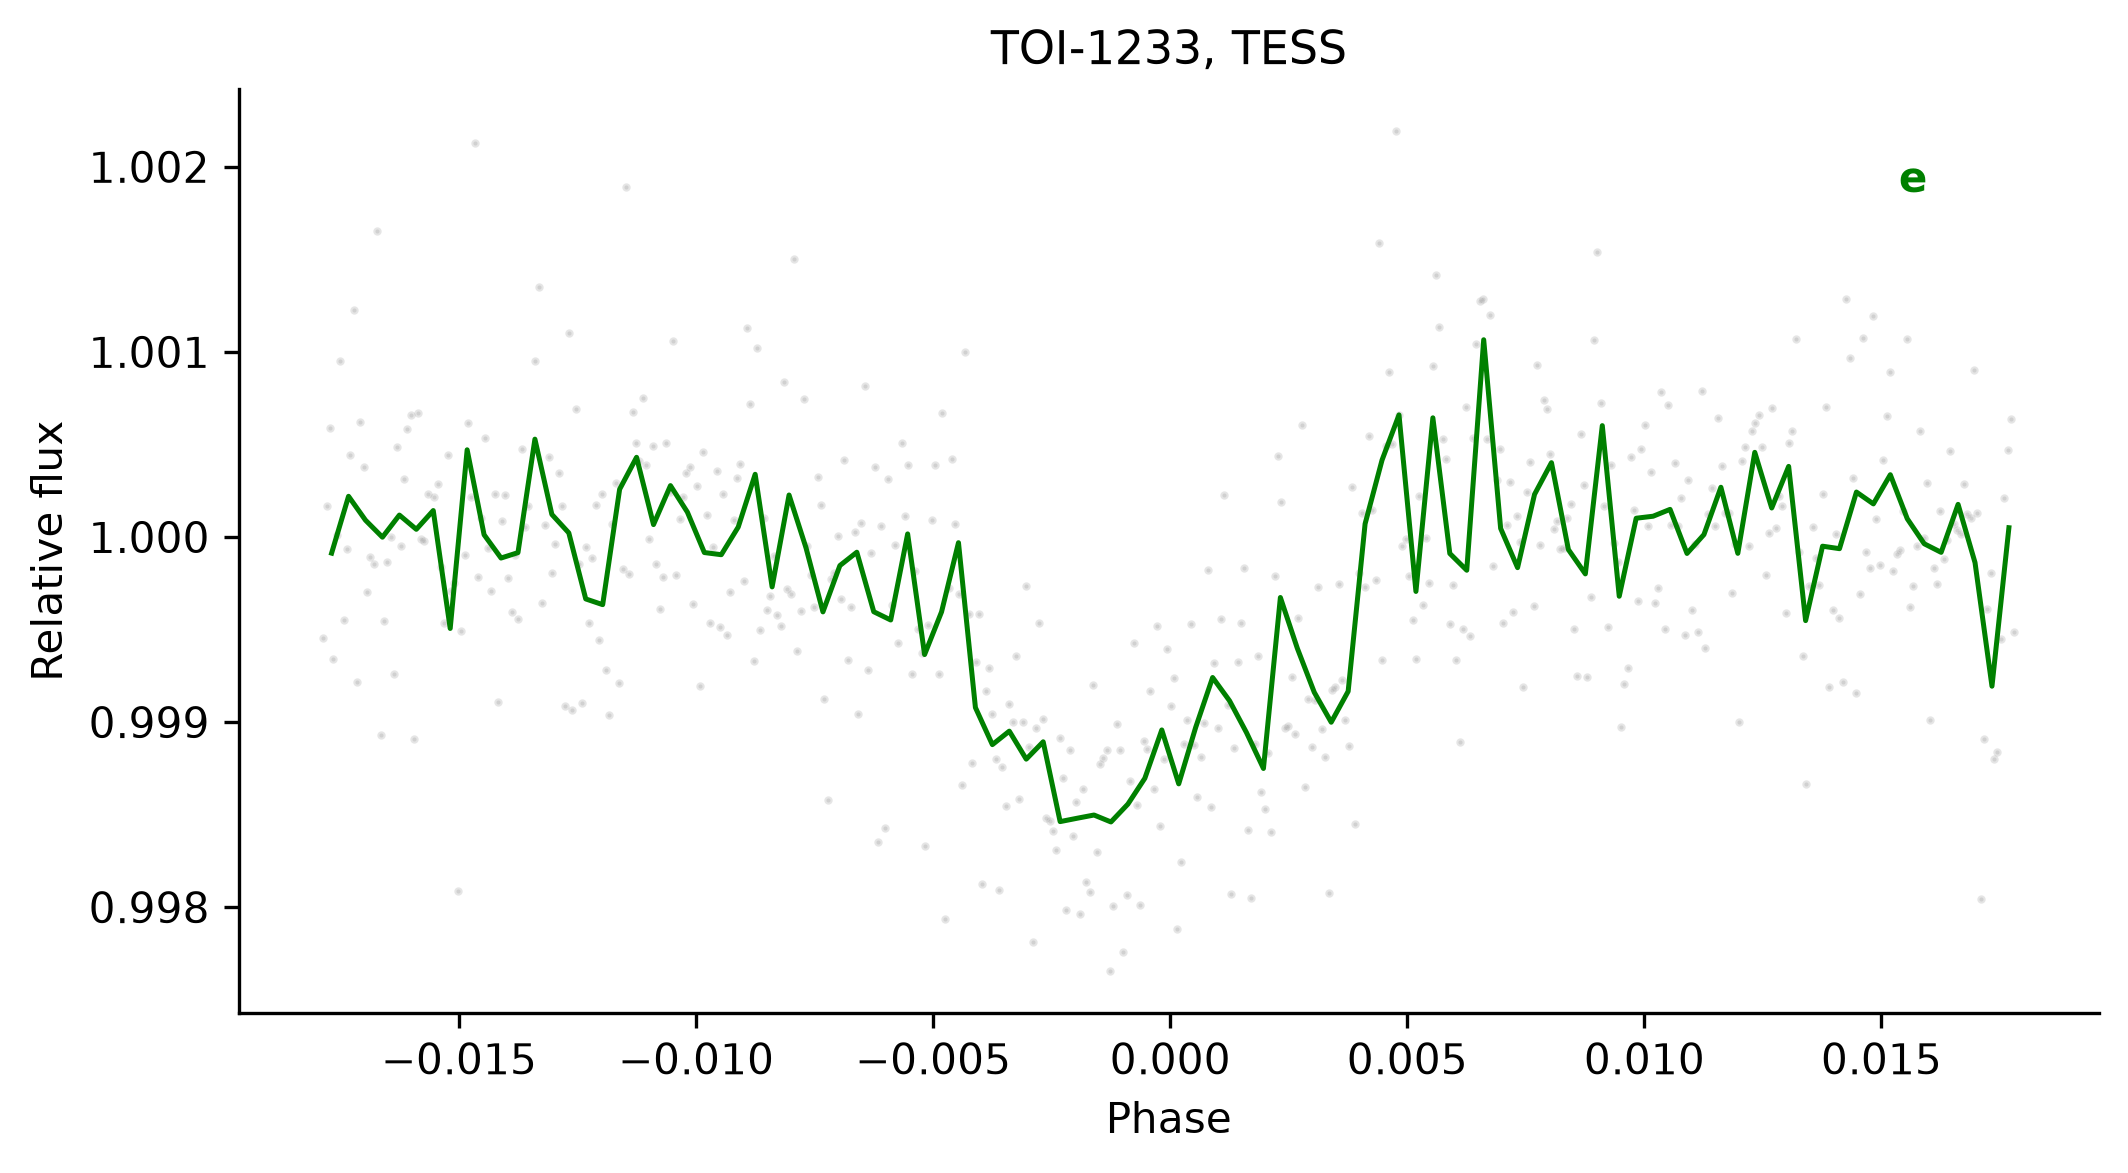

In [2]:
result = run_toi1233_observation(typemodl="PlanetarySystemWithTTVs", typefileplot="png")
visual_path = Path(result["listpathdvrp"][0]).parent
print(f"Analyzed target: {result['strgtarg']}")

for planet in "bcde":
    figure_path = next(visual_path.glob(f"PhaseCurve_TESS_{planet}_DetrendedPrimaryCenteredZoom_*.png"))
    narrate(f"Reading from {figure_path}...")
    display(Image(filename=str(figure_path)))